In [21]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def plot_prior(df, sigma, kernel):
    p_0 = np.mean(df['low_lipid'].values)
    p_1 = np.mean(df['0.05'].values)

    prior_normalized = df.copy()
    prior_normalized = (prior_normalized - p_0) / (p_1 - p_0)

    min_normalized_prior = prior_normalized['low_lipid'].min()

    plt.figure(figsize=(14,6))
    sns.boxplot(data=np.log10(prior_normalized - min_normalized_prior + 1e-5))
    plt.title(f'Log Normalized Prior Values at {sigma} (k={kernel})')
    plt.ylabel('Log Normalized Prior Values')
    plt.grid(True)
    plt.show()

In [24]:
def plot_all(prior_dir, kernel):
    res = []
    sigma_cols = ['0.05', '0.1', '0.15', '0.2']
    x_labels = ['low_lipid'] + sigma_cols
    x_positions = [0.0] + [float(s) for s in sigma_cols]
    flag = False

    # collect prior files
    prior_files = [fn for fn in os.listdir(prior_dir) if fn.endswith('prior.csv')]

    # partition into sigma files and the generic 'prior.csv'
    sigma_files = []
    generic_files = []
    for fn in prior_files:
        base = fn[:-10]  # strip "_prior.csv"
        if base == '':
            generic_files.append(fn)
        else:
            try:
                sigma_val = float(base)
                sigma_files.append((sigma_val, fn))
            except ValueError:
                # unexpected name, treat as generic
                generic_files.append(fn)

    # sort sigma_files by numeric sigma ascending
    sigma_files.sort(key=lambda x: x[0])
    # build iteration order: sorted sigma filenames first, then generic files (if any)
    ordered_files = [fn for (_, fn) in sigma_files] + generic_files

    for fn in ordered_files:
        path = os.path.join(prior_dir, fn)
        prior = pd.read_csv(path)

        # call your plotting function (it should display per-file boxplot)
        plot_prior(prior, fn[:-10], kernel)

        # Only collect stats when the file corresponds to a sigma (has length > 9 as in your code)
        if len(fn) > 9:
            flag = True
            # compute for each x_label
            for idx in range(len(x_labels)):
                col = x_labels[idx]
                if col not in prior.columns:
                    # skip missing columns
                    continue
                prior_values = prior[col].values
                res.append({
                    'sigma': float(fn[:-10]),
                    'gaussian': x_positions[idx],
                    'mean': np.mean(prior_values),
                    'std': np.std(prior_values)
                })

    if flag:
        res_df = pd.DataFrame(res)
        # Ensure numeric types
        res_df['sigma'] = res_df['sigma'].astype(float)
        res_df['gaussian'] = res_df['gaussian'].astype(float)
        res_df['mean'] = res_df['mean'].astype(float)
        res_df['std'] = res_df['std'].astype(float)

        unique_sigmas = np.sort(res_df['sigma'].unique())
        gaussian_order = sorted(res_df['gaussian'].unique())

        plt.figure(figsize=(8, 6))
        cmap = plt.get_cmap('tab10')
        for i, sigma in enumerate(unique_sigmas):
            df_sigma = res_df[res_df['sigma'] == sigma]

            # Reindex df_sigma by gaussian_order to ensure consistent x ordering
            df_sigma_indexed = df_sigma.set_index('gaussian').reindex(gaussian_order)

            x = np.array(gaussian_order)
            y = df_sigma_indexed['mean'].values
            yerr = df_sigma_indexed['std'].values

            # Plot line and shaded std (handle NaNs gracefully)
            plt.plot(x, y, marker='o', label=f"{sigma:.2f}", color=cmap(i % 10))
            lower = y - yerr
            upper = y + yerr
            plt.fill_between(x, lower, upper, color=cmap(i % 10), alpha=0.2)

        plt.yscale('log')

        plt.xlabel('Gaussian perturbation (PSNR positions)')
        plt.xticks(x, [str(xv) for xv in x])  # show numeric labels, or use custom labels
        plt.ylabel('prior mean')
        plt.title(f'Prior mean ± std for each sigma (k={kernel})')
        plt.grid(True)
        plt.legend(title='sigma')
        plt.tight_layout()
        plt.show()

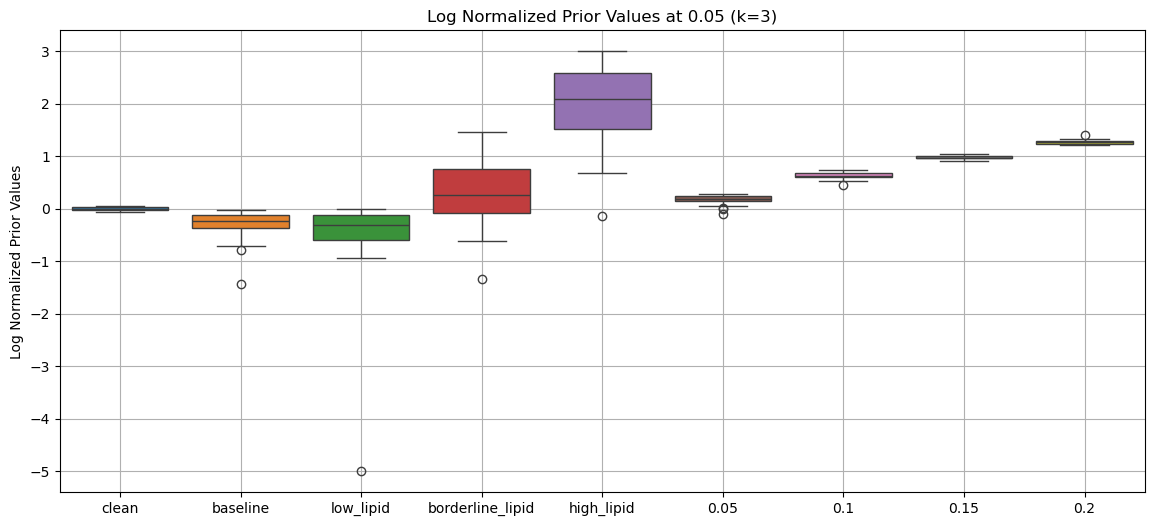

/cis/home/yhe140/miniconda3/envs/lpn_new/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


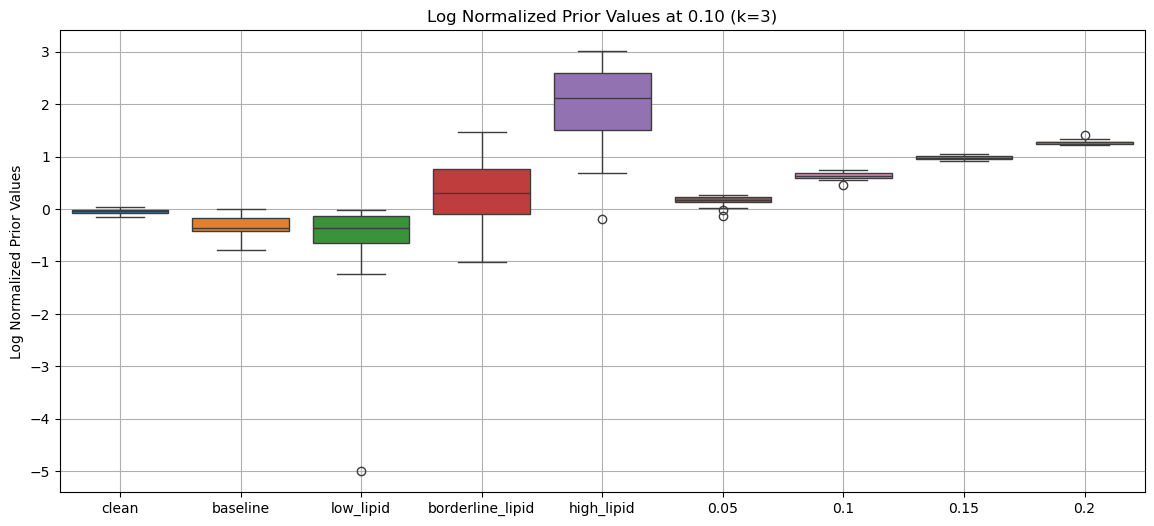

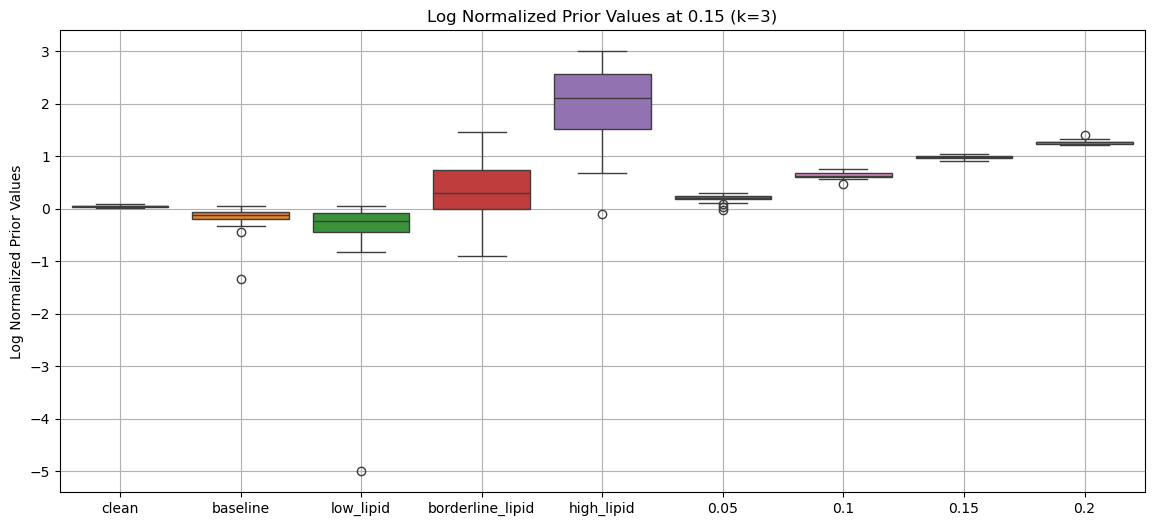

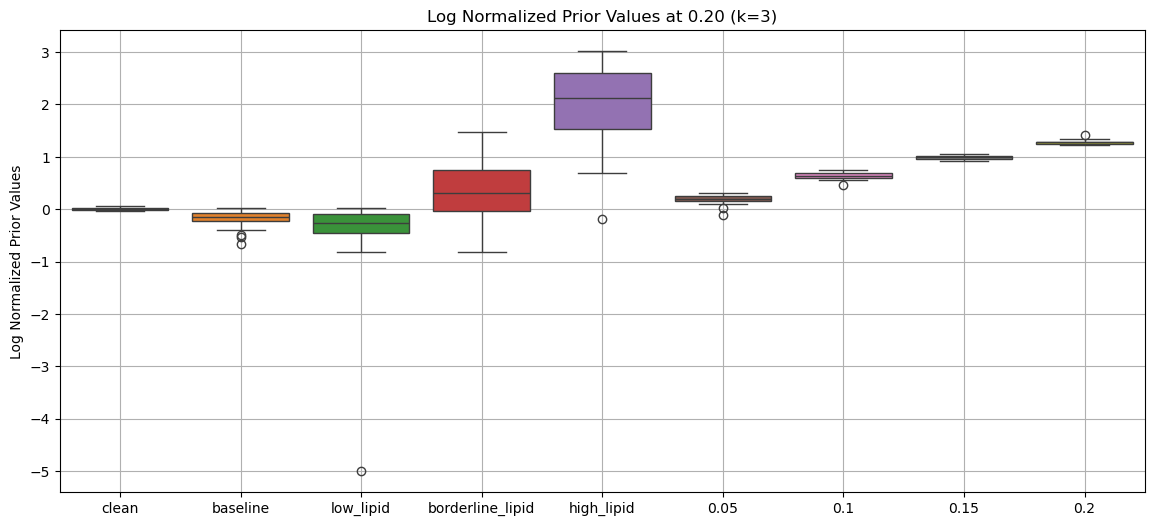

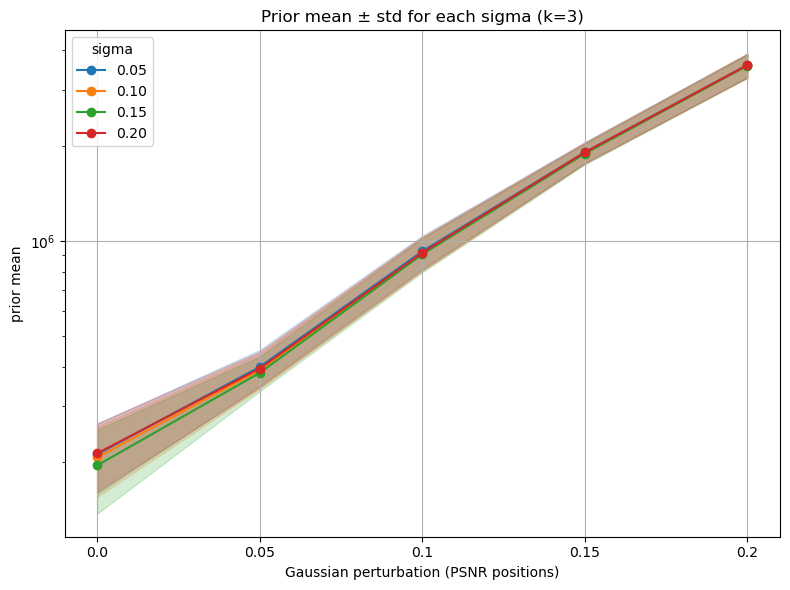

/cis/home/yhe140/miniconda3/envs/lpn_new/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


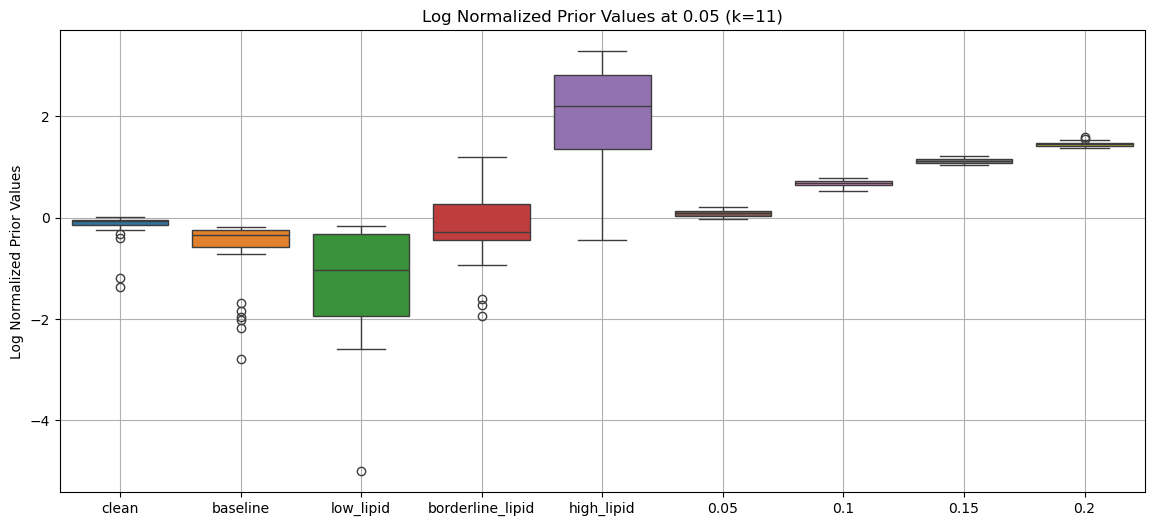

/cis/home/yhe140/miniconda3/envs/lpn_new/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


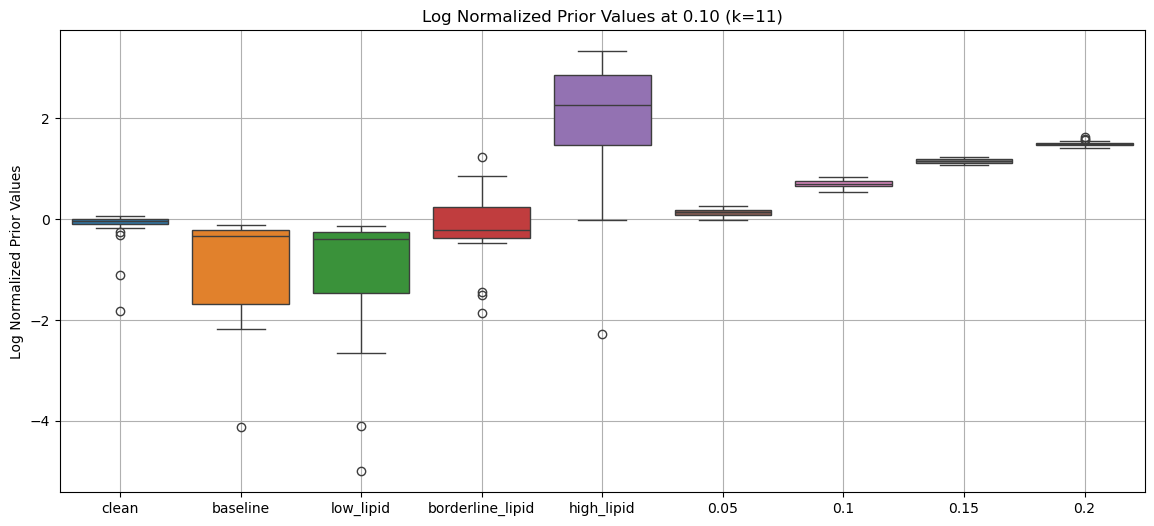

/cis/home/yhe140/miniconda3/envs/lpn_new/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


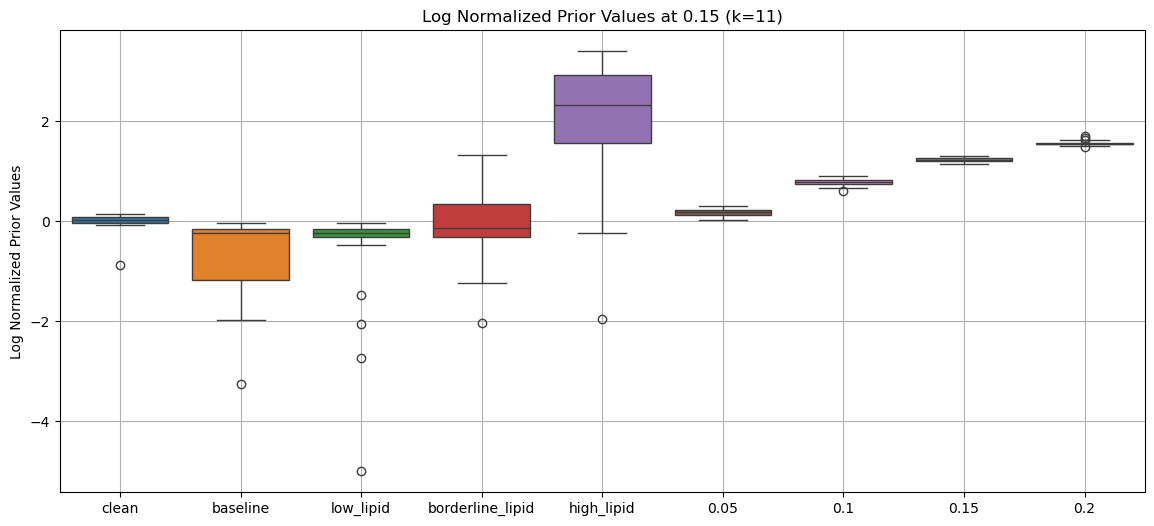

/cis/home/yhe140/miniconda3/envs/lpn_new/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


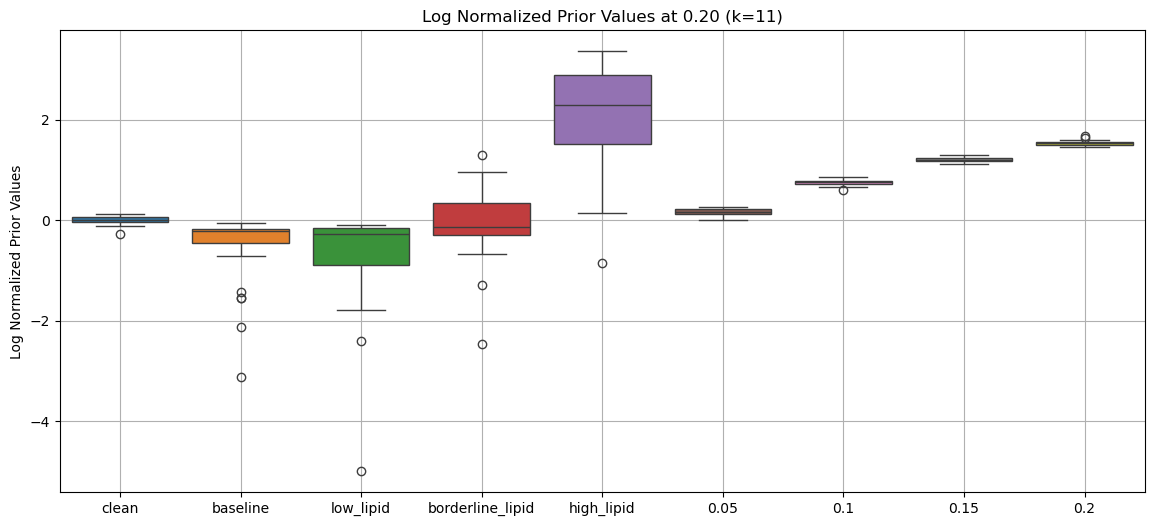

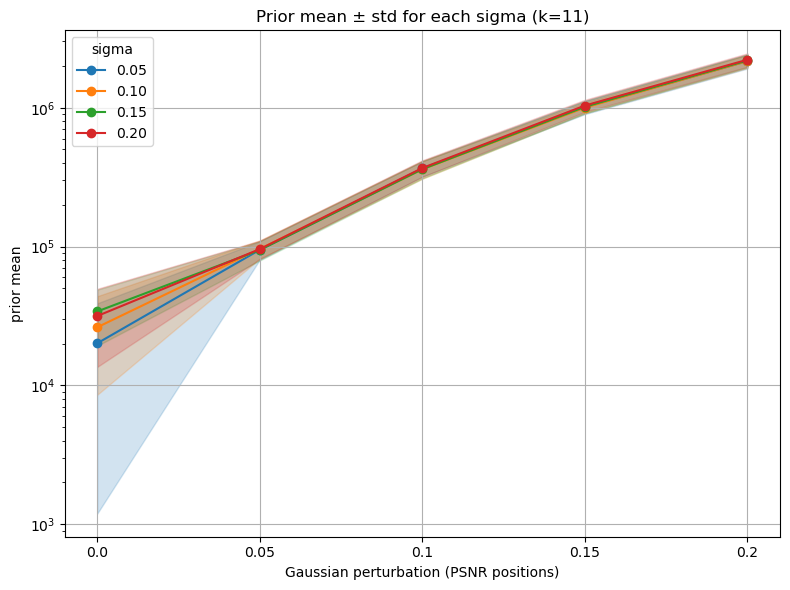

In [25]:
for kernel in [3,11]:
    prior_dir = f'../savings/lpn_cond_mrs_h_64_k_{kernel}_n_(0.05_0.2)/prior/'
    plot_all(prior_dir, kernel)

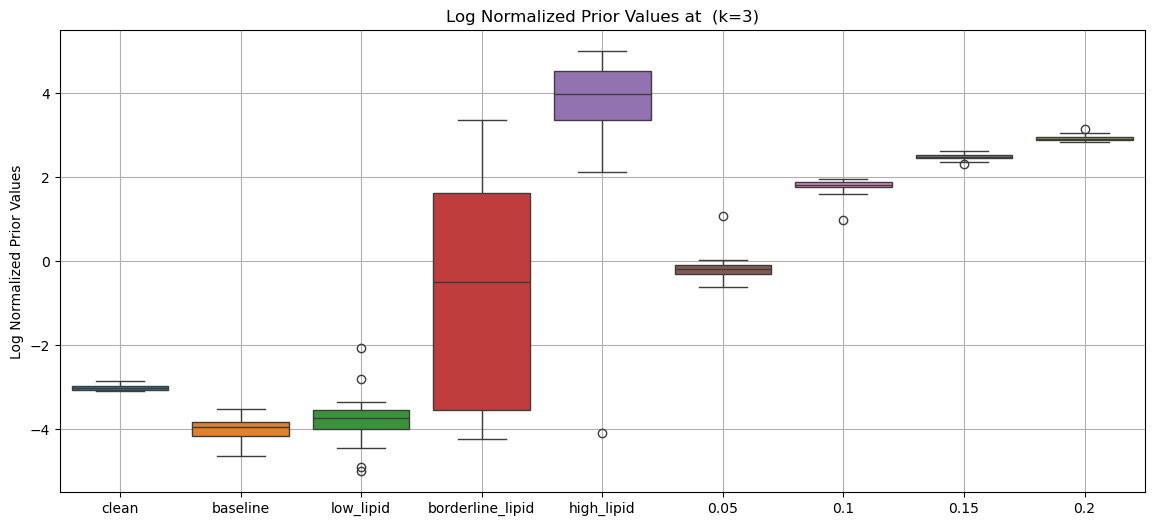

In [26]:
prior_dir = '../savings/lpn_mrs_h_32_k_3_n_0.1/prior/'
plot_all(prior_dir, kernel=3)